# Celsius Event Exploration

The Celsius case represents a different type of crypto market stress from the LUNA collapse.

While LUNA primarily illustrates market and stablecoin peg risk, Celsius introduces an additional operational dimension: **access and liquidity risk**. On 13 June 2022, Celsius paused withdrawals, swaps, and transfers between accounts, restricting customers' ability to access assets held on the platform.

This analysis first examines the broader BTC and ETH market environment around the event, followed by hourly market behavior around the withdrawal halt.

The objective is to distinguish between:

- broader crypto market stress already developing around the event, and
- the specific operational shock created by the loss of access to funds.


In [34]:
import pandas as pd
import matplotlib.pyplot as plt


## 1. Daily Market Context
The daily analysis covers **7–20 June 2022**, capturing the market environment before and after the Celsius withdrawal halt on 13 June.

BTC and ETH are used as indicators of broader crypto market stress. Daily closing prices and percentage returns are examined to identify whether the withdrawal halt coincided with an isolated market move or occurred during a broader period of market deterioration.

In [14]:
crypto_daily_processed = pd.read_csv('../data/processed/daily/crypto_daily_processed.csv', parse_dates=["date"])
crypto_daily_processed.head()

,date,btc_close,eth_close,usdc_close,usdt_close,btc_high,eth_high,usdc_high,usdt_high,btc_low,...,usdc_low,usdt_low,btc_open,eth_open,usdc_open,usdt_open,btc_volume,eth_volume,usdc_volume,usdt_volume
0,2020-01-01,7200.174316,130.802002,1.004079,0.999836,7254.330566,132.835358,1.006639,1.006873,7174.944336,...,1.001989,0.994924,7194.892090,129.630661,1.003730,0.999571,1.856566e+10,7.935230e+09,242586528.0,2.150314e+10
1,2020-01-02,6985.470215,127.410179,1.005017,1.001565,7212.155273,130.820038,1.012636,1.008451,6935.270020,...,1.002543,0.986515,7202.551270,130.820038,1.004431,0.999788,2.080208e+10,8.032709e+09,318268134.0,2.421231e+10
2,2020-01-03,7344.884277,134.171707,1.005273,1.004192,7413.715332,134.554016,1.007928,1.022286,6914.996094,...,0.988455,0.988027,6984.428711,127.411263,1.005357,1.001183,2.811148e+10,1.047685e+10,374792167.0,3.242029e+10
3,2020-01-04,7410.656738,135.069366,1.009466,1.007472,7427.385742,136.052719,1.018391,1.013633,7309.514160,...,1.001273,0.999160,7345.375488,134.168518,1.004818,1.003510,1.844427e+10,7.430905e+09,334494308.0,2.158563e+10
4,2020-01-05,7411.317383,136.276779,1.008497,1.006197,7544.497070,139.410202,1.018718,1.016161,7400.535645,...,1.003932,1.001758,7410.451660,135.072098,1.008748,1.009921,1.972507e+10,7.526675e+09,334597544.0,2.409014e+10


In [15]:
celsius_daily = crypto_daily_processed[
    (crypto_daily_processed["date"] >= "2022-06-07") &
    (crypto_daily_processed["date"] <= "2022-06-20")
]
celsius_daily[["date", "btc_close", "eth_close"]]

,date,btc_close,eth_close
888,2022-06-07,31155.478516,1814.048340
889,2022-06-08,30214.355469,1793.572266
890,2022-06-09,30111.998047,1789.826050
891,2022-06-10,29083.804688,1665.042236
892,2022-06-11,28360.810547,1529.663452
893,2022-06-12,26762.648438,1445.216553
894,2022-06-13,22487.388672,1204.582764
895,2022-06-14,22206.792969,1211.662842
896,2022-06-15,22572.839844,1233.206421
897,2022-06-16,20381.650391,1067.730713


In [16]:
celsius_daily = celsius_daily.copy()

celsius_daily["btc_return_pct"] = (celsius_daily["btc_close"].pct_change() * 100)

celsius_daily["eth_return_pct"] = (celsius_daily["eth_close"].pct_change() * 100)
celsius_daily[["date", "btc_close", "eth_close", "btc_return_pct", "eth_return_pct"]]

,date,btc_close,eth_close,btc_return_pct,eth_return_pct
888,2022-06-07,31155.478516,1814.048340,NaN,NaN
889,2022-06-08,30214.355469,1793.572266,-3.020731,-1.128750
890,2022-06-09,30111.998047,1789.826050,-0.338771,-0.208869
891,2022-06-10,29083.804688,1665.042236,-3.414564,-6.971840
892,2022-06-11,28360.810547,1529.663452,-2.485899,-8.130652
893,2022-06-12,26762.648438,1445.216553,-5.635107,-5.520620
894,2022-06-13,22487.388672,1204.582764,-15.974726,-16.650362
895,2022-06-14,22206.792969,1211.662842,-1.247791,0.587762
896,2022-06-15,22572.839844,1233.206421,1.648355,1.778018
897,2022-06-16,20381.650391,1067.730713,-9.707194,-13.418330


In [17]:
celsius_daily[["date", "btc_close", "eth_close", "btc_return_pct", "eth_return_pct"]].sort_values(by='btc_return_pct').head()

,date,btc_close,eth_close,btc_return_pct,eth_return_pct
894,2022-06-13,22487.388672,1204.582764,-15.974726,-16.650362
897,2022-06-16,20381.650391,1067.730713,-9.707194,-13.418330
899,2022-06-18,19017.642578,993.636780,-7.101781,-8.548629
893,2022-06-12,26762.648438,1445.216553,-5.635107,-5.520620
891,2022-06-10,29083.804688,1665.042236,-3.414564,-6.971840


In [18]:
celsius_daily[["date", "btc_close", "eth_close", "btc_return_pct", "eth_return_pct"]].sort_values(by='eth_return_pct').head()

,date,btc_close,eth_close,btc_return_pct,eth_return_pct
894,2022-06-13,22487.388672,1204.582764,-15.974726,-16.650362
897,2022-06-16,20381.650391,1067.730713,-9.707194,-13.418330
899,2022-06-18,19017.642578,993.636780,-7.101781,-8.548629
892,2022-06-11,28360.810547,1529.663452,-2.485899,-8.130652
891,2022-06-10,29083.804688,1665.042236,-3.414564,-6.971840


Text(0, 0.5, 'BTC Price (USD)')

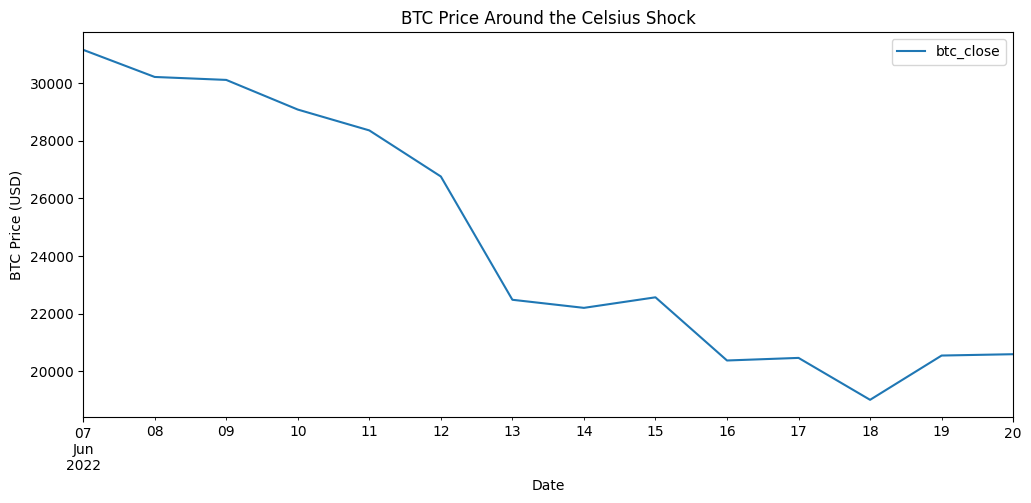

In [19]:
ax = celsius_daily.plot(
    x="date",
    y="btc_close",
    figsize=(12, 5),
    title="BTC Price Around the Celsius Shock"
)

ax.set_xlabel("Date")
ax.set_ylabel("BTC Price (USD)")

Text(0, 0.5, 'Daily Return (%)')

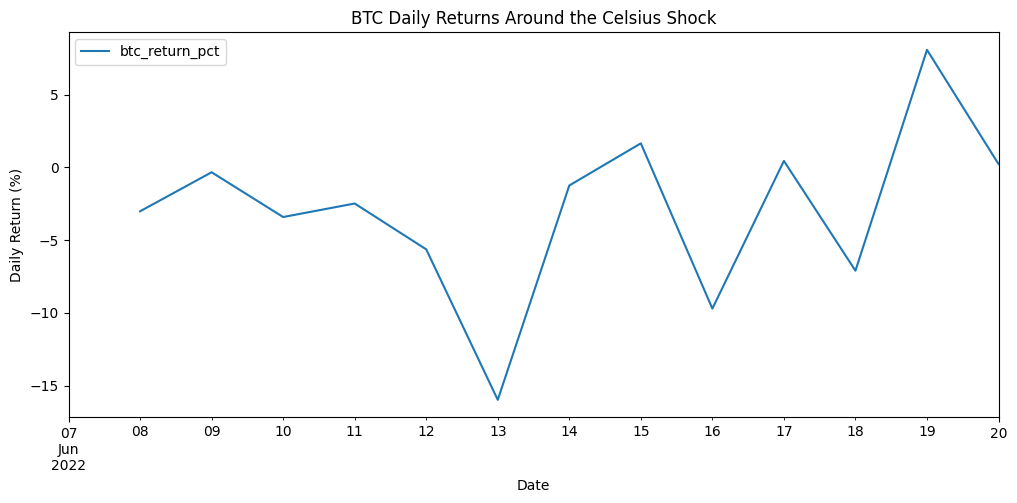

In [20]:
ax = celsius_daily.plot(
    x="date",
    y="btc_return_pct",
    figsize=(12, 5),
    title="BTC Daily Returns Around the Celsius Shock"
)

ax.set_xlabel("Date")
ax.set_ylabel("Daily Return (%)")

Text(0, 0.5, 'ETH Price (USD)')

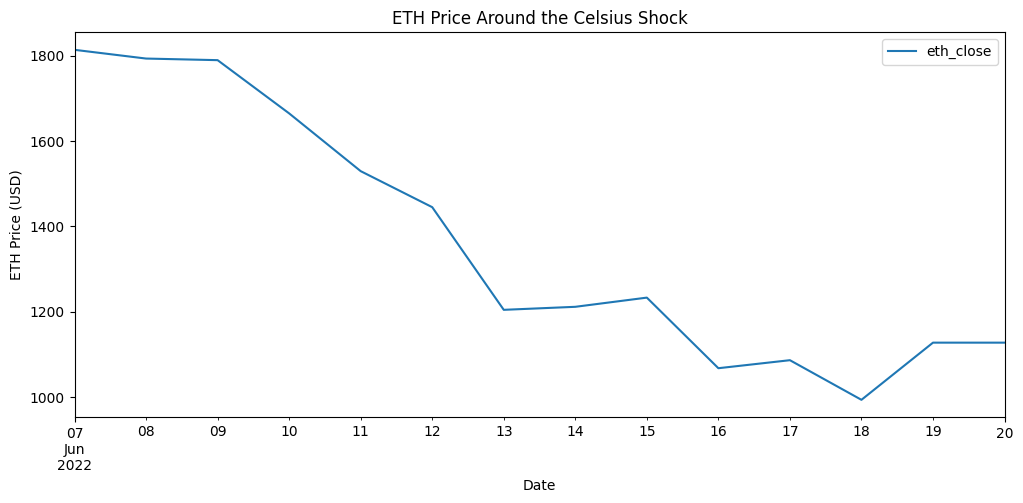

In [21]:
ax = celsius_daily.plot(
    x="date",
    y="eth_close",
    figsize=(12, 5),
    title="ETH Price Around the Celsius Shock"
)

ax.set_xlabel("Date")
ax.set_ylabel("ETH Price (USD)")

Text(0, 0.5, 'Daily Return (%)')

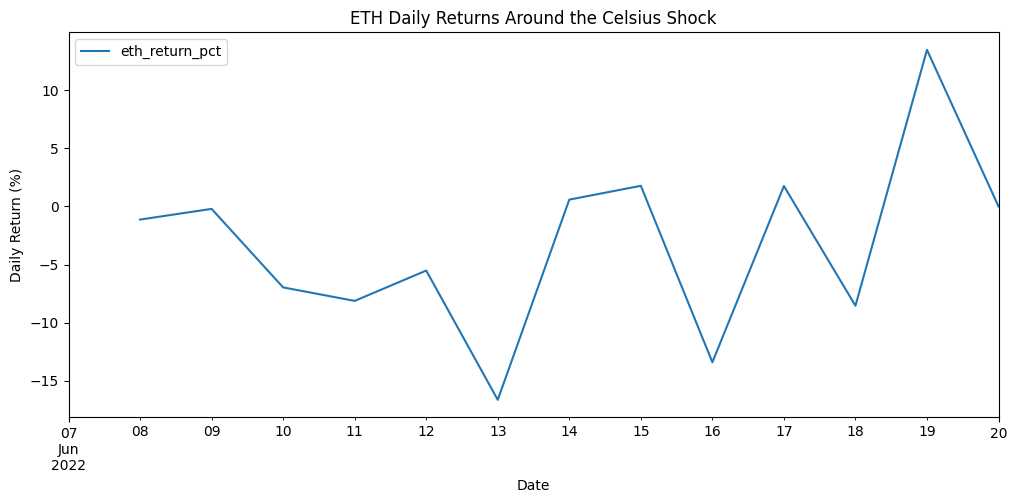

In [22]:
ax = celsius_daily.plot(
    x="date",
    y="eth_return_pct",
    figsize=(12, 5),
    title="ETH Daily Returns Around the Celsius Shock"
)

ax.set_xlabel("Date")
ax.set_ylabel("Daily Return (%)")

### Daily Observation

BTC and ETH were already declining before 13 June, but the sell-off accelerated substantially on that date.

BTC declined by approximately **15.9%** and ETH by **16.6%** compared with the previous daily close, representing the largest daily decline for both assets within the selected event window.

However, the market stress was not limited to 13 June. Negative returns were already visible during the preceding days, particularly in ETH, and substantial declines occurred again later in the window.

This indicates that the Celsius withdrawal halt occurred during a broader period of crypto market deterioration rather than against a stable market baseline.

For this reason, hourly data around the withdrawal halt is examined next to understand the timing of market stress in greater detail.

## 2. Hourly Market Stress
The hourly analysis provides a more granular view of BTC and ETH movements around the Celsius withdrawal halt.

The purpose is not to assume that Celsius caused the observed market movements, but to determine whether the operational event occurred before, during, or after the most intense periods of market stress.

In [23]:
btc_celsius_hourly = pd.read_csv('../data/processed/hourly/binance/btc_celsius_hourly_processed.csv', parse_dates=["open_time"])
btc_celsius_hourly.head()

,open_time,open,high,low,close,volume
0,2022-05-29 00:00:00,29031.33,29045.34,28970.30,29005.47,786.45225
1,2022-05-29 01:00:00,29005.46,29024.65,28900.00,28925.85,940.66592
2,2022-05-29 02:00:00,28925.85,28925.86,28839.21,28904.13,1227.04778
3,2022-05-29 03:00:00,28904.12,28997.21,28876.08,28984.32,719.15298
4,2022-05-29 04:00:00,28984.31,28984.32,28914.96,28941.09,456.89978


In [24]:
celsius_btc_detail = btc_celsius_hourly[
    (btc_celsius_hourly["open_time"] >= "2022-06-12") &
    (btc_celsius_hourly["open_time"] < "2022-06-17")
].copy()

In [26]:
celsius_btc_detail["btc_hourly_return_pct"] = (celsius_btc_detail["close"].pct_change() * 100)
celsius_btc_detail[["open_time", "close", "btc_hourly_return_pct"]].sort_values(by='btc_hourly_return_pct').head()

,open_time,close,btc_hourly_return_pct
385,2022-06-14 01:00:00,20855.00,-4.156849
374,2022-06-13 14:00:00,22804.62,-3.582455
424,2022-06-15 16:00:00,20723.00,-3.249903
384,2022-06-14 00:00:00,21759.51,-3.236922
338,2022-06-12 02:00:00,27427.48,-2.893391


Text(0, 0.5, 'BTC Price (USDT)')

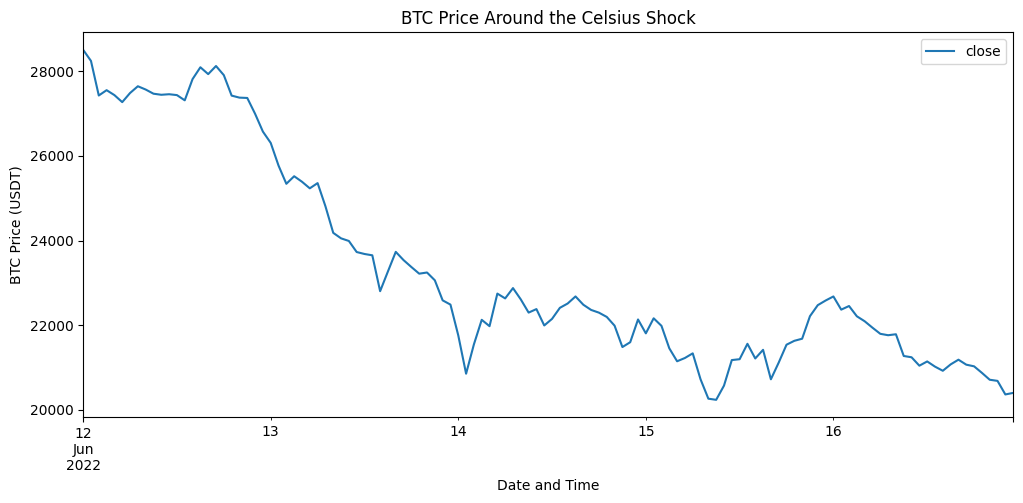

In [27]:
ax = celsius_btc_detail.plot(
    x="open_time",
    y="close",
    figsize=(12, 5),
    title="BTC Price Around the Celsius Shock"
)

ax.set_xlabel("Date and Time")
ax.set_ylabel("BTC Price (USDT)")

Text(0, 0.5, 'BTC Hourly Returns (%)')

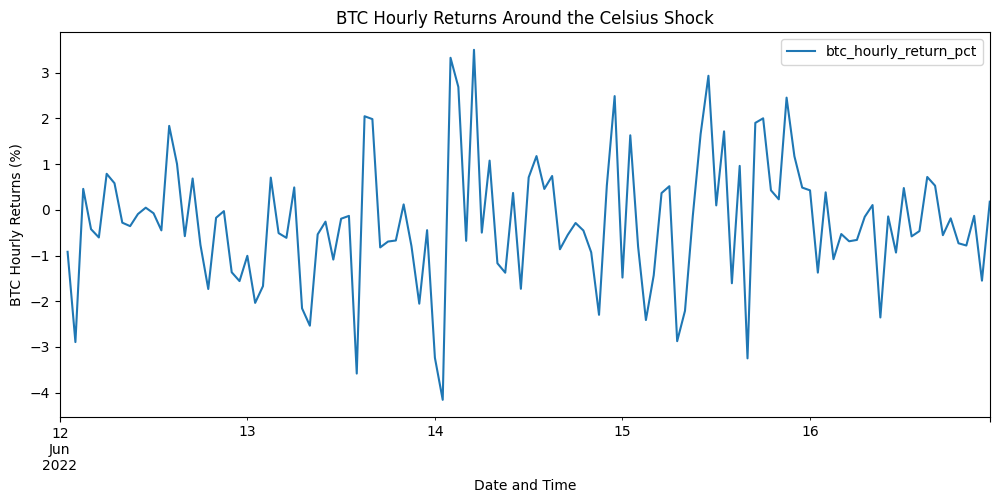

In [28]:
ax = celsius_btc_detail.plot(
    x="open_time",
    y="btc_hourly_return_pct",
    figsize=(12, 5),
    title="BTC Hourly Returns Around the Celsius Shock"
)

ax.set_xlabel("Date and Time")
ax.set_ylabel("BTC Hourly Returns (%)")

In [29]:
eth_celsius_hourly = pd.read_csv('../data/processed/hourly/binance/eth_celsius_hourly_processed.csv', parse_dates=["open_time"])
eth_celsius_hourly.head()

,open_time,open,high,low,close,volume
0,2022-05-29 00:00:00,1792.21,1795.89,1786.78,1789.66,16687.7110
1,2022-05-29 01:00:00,1789.67,1789.80,1772.82,1776.23,23647.5981
2,2022-05-29 02:00:00,1776.22,1776.74,1759.96,1768.57,36374.2147
3,2022-05-29 03:00:00,1768.56,1778.52,1765.01,1776.46,12530.0634
4,2022-05-29 04:00:00,1776.46,1779.28,1769.38,1775.26,10996.7765


In [30]:
celsius_eth_detail = eth_celsius_hourly[
    (eth_celsius_hourly["open_time"] >= "2022-06-12") &
    (eth_celsius_hourly["open_time"] < "2022-06-17")
].copy()

In [31]:
celsius_eth_detail["eth_hourly_return_pct"] = (celsius_eth_detail["close"].pct_change() * 100)
celsius_eth_detail[["open_time", "close", "eth_hourly_return_pct"]].sort_values(by='eth_hourly_return_pct').head()

,open_time,close,eth_hourly_return_pct
385,2022-06-14 01:00:00,1102.52,-5.970849
368,2022-06-13 08:00:00,1206.93,-5.962788
416,2022-06-15 08:00:00,1029.59,-5.920247
338,2022-06-12 02:00:00,1453.29,-4.000396
441,2022-06-16 09:00:00,1128.10,-3.864673


Text(0, 0.5, 'ETH Price (USDT)')

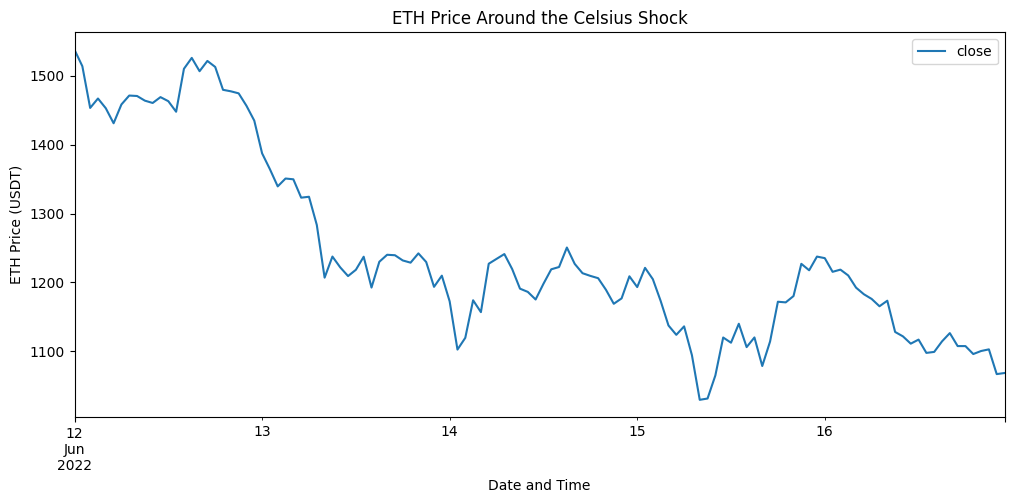

In [32]:
ax = celsius_eth_detail.plot(
    x="open_time",
    y="close",
    figsize=(12, 5),
    title="ETH Price Around the Celsius Shock"
)

ax.set_xlabel("Date and Time")
ax.set_ylabel("ETH Price (USDT)")

Text(0, 0.5, 'ETH Hourly Returns (%)')

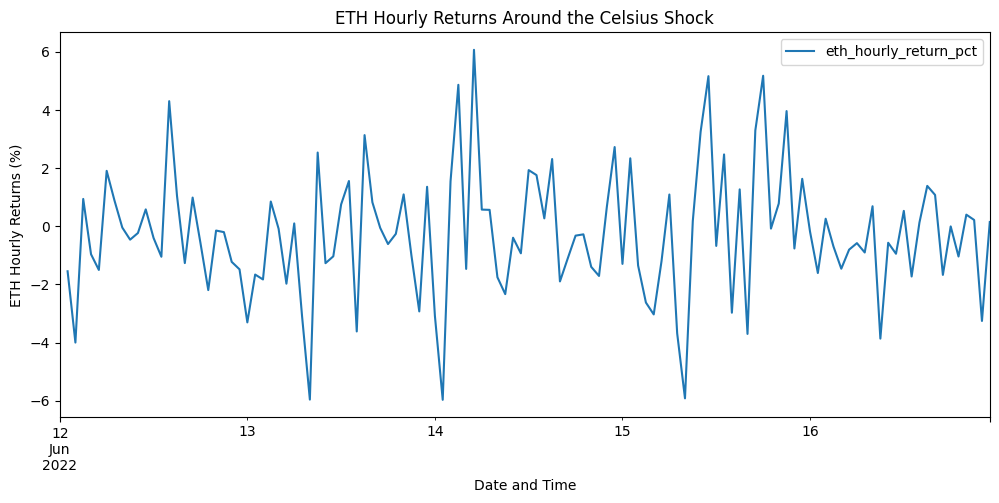

In [33]:
ax = celsius_eth_detail.plot(
    x="open_time",
    y="eth_hourly_return_pct",
    figsize=(12, 5),
    title="ETH Hourly Returns Around the Celsius Shock"
)

ax.set_xlabel("Date and Time")
ax.set_ylabel("ETH Hourly Returns (%)")

### Hourly Observation

Hourly data confirms that substantial market volatility was present throughout the selected period rather than being concentrated in a single observation.

Negative BTC and ETH movements were already visible before 13 June, while significant declines continued after the withdrawal halt. The largest individual hourly decline for both assets within the selected window occurred on 14 June.

This reinforces the daily-level finding that the Celsius event occurred within an already highly stressed crypto market.

However, price data alone cannot determine whether the withdrawal halt caused the subsequent market movements. A precise event timestamp is therefore required to position the operational event within the observed market timeline.

## 3. Event Timeline and T0 Definition

Daily and hourly market data show that crypto market stress was already developing before the Celsius withdrawal halt and continued afterward.

Unlike the LUNA case, however, the Celsius event provides a clearly identifiable operational timestamp.

Celsius publicly announced the suspension of withdrawals, swaps, and transfers between accounts on **13 June 2022 at 02:19 UTC**.

For this case study, this timestamp is therefore defined as:

**T0_event = 13 June 2022, 02:19 UTC**

T0 represents the observable operational event — the withdrawal halt — rather than the beginning of the broader crypto market sell-off.

This distinction is important because the BTC and ETH data indicate that market deterioration preceded the announcement. The Celsius event therefore represents an **access and liquidity shock occurring within an already stressed market environment**.

In [39]:

celsius_t0_event = pd.Timestamp("2022-06-13 02:19:00", tz="UTC")

## 4. Operational Liquidity Stress Scenario

Market price stability does not necessarily mean that funds remain available for operational use.

To illustrate this risk, the analysis models a hypothetical **100,000 USDT operational balance** under two conditions:

- **Celsius scenario:** the balance is fully accessible before the withdrawal halt and unavailable after `T0_event`.
- **Accessible venue scenario:** the same balance remains fully accessible throughout the event window.

The USDT balance is valued in EUR using the observed USDT/EUR market price.

This is a deterministic stress scenario rather than an estimate of a specific historical Celsius account. The 100,000 USDT exposure is hypothetical, and the Celsius withdrawal restriction is modeled as a change in availability from **100% to 0%** after T0.

The objective is to distinguish between three concepts:

- **Market Value** — the observed EUR value of the USDT balance.
- **Available Operational Liquidity** — the value that remains accessible for payments or settlements.
- **Liquidity at Risk** — market value that exists but cannot be accessed for operational use.

In [55]:
usdt_celsius = pd.read_csv(
    "../data/processed/hourly/coinbase/usdt_celsius_hourly_processed.csv",
    parse_dates=["timestamp"]
)

usdt_celsius.head()

,timestamp,low,high,open,close,volume
0,2022-05-29 00:00:00+00:00,0.93076,0.93120,0.93092,0.93120,56697.16
1,2022-05-29 01:00:00+00:00,0.93076,0.93120,0.93119,0.93077,38433.22
2,2022-05-29 02:00:00+00:00,0.93076,0.93119,0.93077,0.93110,20249.56
3,2022-05-29 03:00:00+00:00,0.93102,0.93119,0.93110,0.93110,27490.58
4,2022-05-29 04:00:00+00:00,0.93110,0.93119,0.93118,0.93110,9760.75


In [56]:
initial_balance_usdt = 100_000

celsius_balance = (
    usdt_celsius[["timestamp", "close"]]
    .rename(columns={"close": "usdt_eur_price"})
    .copy()
)

# EUR market value of the 100,000 USDT balance
celsius_balance["market_value_eur"] = (
    initial_balance_usdt
    * celsius_balance["usdt_eur_price"]
)

# Celsius-specific availability assumption
celsius_balance["celsius_availability_ratio"] = (
    celsius_balance["timestamp"] < celsius_t0_event
).astype(int)

# Operational liquidity available on Celsius
celsius_balance["celsius_available_value_eur"] = (
    celsius_balance["market_value_eur"]
    * celsius_balance["celsius_availability_ratio"]
)

# Operational liquidity available on an unaffected venue
celsius_balance["accessible_venue_value_eur"] = (
    celsius_balance["market_value_eur"]
)

# Liquidity at risk
celsius_balance["celsius_liquidity_at_risk_eur"] = (
    celsius_balance["market_value_eur"]
    - celsius_balance["celsius_available_value_eur"]
)

celsius_balance["accessible_venue_liquidity_at_risk_eur"] = (
    celsius_balance["market_value_eur"]
    - celsius_balance["accessible_venue_value_eur"]
)

celsius_balance.head()

,timestamp,usdt_eur_price,market_value_eur,celsius_availability_ratio,celsius_available_value_eur,accessible_venue_value_eur,celsius_liquidity_at_risk_eur,accessible_venue_liquidity_at_risk_eur
0,2022-05-29 00:00:00+00:00,0.93120,93120.0,1,93120.0,93120.0,0.0,0.0
1,2022-05-29 01:00:00+00:00,0.93077,93077.0,1,93077.0,93077.0,0.0,0.0
2,2022-05-29 02:00:00+00:00,0.93110,93110.0,1,93110.0,93110.0,0.0,0.0
3,2022-05-29 03:00:00+00:00,0.93110,93110.0,1,93110.0,93110.0,0.0,0.0
4,2022-05-29 04:00:00+00:00,0.93110,93110.0,1,93110.0,93110.0,0.0,0.0


In [57]:
before_t0 = (
    celsius_balance[
        celsius_balance["timestamp"] < celsius_t0_event
    ]
    .iloc[-1]
)

after_t0 = (
    celsius_balance[
        celsius_balance["timestamp"] >= celsius_t0_event
    ]
    .iloc[0]
)

before_t0, after_t0

(timestamp                                 2022-06-13 02:00:00+00:00
 usdt_eur_price                                              0.95226
 market_value_eur                                            95226.0
 celsius_availability_ratio                                        1
 celsius_available_value_eur                                 95226.0
 accessible_venue_value_eur                                  95226.0
 celsius_liquidity_at_risk_eur                                   0.0
 accessible_venue_liquidity_at_risk_eur                          0.0
 Name: 362, dtype: object,
 timestamp                                 2022-06-13 03:00:00+00:00
 usdt_eur_price                                              0.95244
 market_value_eur                                            95244.0
 celsius_availability_ratio                                        0
 celsius_available_value_eur                                     0.0
 accessible_venue_value_eur                                  95244.0
 celsiu

In [58]:
operational_liquidity_summary = pd.DataFrame({
    "Metric": [
        "Operational balance",
        "Market value after T0",
        "Availability ratio after T0",
        "Available operational liquidity",
        "Liquidity at risk"
    ],
    "Celsius": [
        "100,000 USDT",
        f"€{after_t0['market_value_eur']:,.0f}",
        f"{after_t0['celsius_availability_ratio'] * 100:.0f}%",
        f"€{after_t0['celsius_available_value_eur']:,.0f}",
        f"€{after_t0['celsius_liquidity_at_risk_eur']:,.0f}"
    ],
    "Accessible venue": [
        "100,000 USDT",
        f"€{after_t0['market_value_eur']:,.0f}",
        "100%",
        f"€{after_t0['accessible_venue_value_eur']:,.0f}",
        f"€{after_t0['accessible_venue_liquidity_at_risk_eur']:,.0f}"
    ]
})

operational_liquidity_summary

,Metric,Celsius,Accessible venue
0,Operational balance,"100,000 USDT","100,000 USDT"
1,Market value after T0,"€95,244","€95,244"
2,Availability ratio after T0,0%,100%
3,Available operational liquidity,€0,"€95,244"
4,Liquidity at risk,"€95,244",€0


### Operational Liquidity Finding

At the first hourly market observation after the Celsius withdrawal halt, the hypothetical **100,000 USDT** balance retained a market value of approximately **€95.2k**.

The modeled difference between the two scenarios is entirely driven by asset accessibility.

On Celsius, the withdrawal restriction reduces the availability ratio from 100% to 0%, leaving approximately **€95.2k of market-valued liquidity unavailable for operational use**.

The same balance held on an unaffected accessible venue remains fully available.

This demonstrates that **market value and operational liquidity are separate dimensions of risk**: a stablecoin balance can retain its market value while becoming unusable for payments and settlements.

## 5. Celsius Case Conclusion

The Celsius event highlights a different dimension of stablecoin settlement risk from the LUNA case.

BTC and ETH were already experiencing substantial market stress before the withdrawal halt, with volatility continuing after the event. The halt therefore occurred within an already deteriorating crypto market rather than marking the beginning of the broader sell-off.

For the hypothetical 100,000 USDT operational balance, the primary risk was not an immediate loss of market value but a loss of **asset accessibility**. At the first hourly observation after T0, the balance retained a market value of approximately **€95.2k**, while the modeled available operational liquidity on Celsius fell to **€0**.

The counterfactual accessible-venue scenario shows that the same asset, at the same market price and at the same point in time, would have remained fully usable.

The case therefore demonstrates that stablecoin settlement resilience depends not only on price stability, but also on **counterparty and access risk**. A balance can remain valuable on the market while becoming unavailable for payments or settlements.